In [14]:
# 玻尔兹曼测量值计算通用代码
# copyright@pifuyuini

# 导入必要的库
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 绘图设置
# 风格
plt.style.use('seaborn-v0_8-whitegrid')
# 全局设置
config = {'font.family':'Times New Roman', 'figure.dpi':500, 'figure.figsize':(10,8), 'axes.labelsize':20}
plt.rcParams.update(config)
# 配色
from matplotlib.colors import LinearSegmentedColormap
colors = ['#3e324a', '#475d7b', '#97c6c0', '#e26e1b', '#4df8e8'] # FireFly!
cmap = LinearSegmentedColormap.from_list("custom_cmap", colors)

# 其它
import scipy.stats as stats

### 数据分析的大致思路

1. 数据的质量评定，详见相关性检验的代码“correlation_test_of_data_analysis_taking_experiment_APL1_1_A_as_an_example”；
2. 计算玻尔兹曼常数；
3. 误差评定；
4. 分析测量结果与频率的关系。

In [ ]:
# 读取数据

data_set_remote = []
data_set_local = []
data_set_base = []

# 本地数据读取
for i in range(8):
    file_name = 'data-set/local/Data'+str(i+1)+'.csv'
    data_set_local.append(pd.read_csv(file_name, skiprows=1))

# 遥测数据读取
for i in range(8):
    file_name = 'data-set/remote/Data'+str(i+2)+'.csv'
    data_set_remote.append(pd.read_csv(file_name, skiprows=1))

# 本底噪声
for i in range(8):
    file_name = 'data-set/base/DataB'+str(i+1)+'.csv'
    data_set_base.append(pd.read_csv(file_name, skiprows=1))

In [3]:
# 计算玻尔兹曼常数
def bcm(temperature, f, tau, resistance, c_slope, nx2, nB2):
    '''
    Boltzmann constant measurements

    ***Formula***  
    k_B = (vN**2) / (4 * ENBW * temperature * resistance)  
    ENBW = c_slope / tau  
    vN**2 = (1 + (omega * R_in * C_in)**2) * nx**2 - nB**2  

    ***Data Example***  
    Data3-remote:  
    f = 6.666kHz  
    tau = 100ms  
    Slope = 24dB/oct  
    Sample Rate(S) = 1s  
    T = 298.0K  

    ***function***  
    Input: temperature, f, tau, resistance, c_slope, nx**2, nB**2  
    output: k_B  
    '''
    R_in = resistance
    C_in = 68e-12
    omega = 2 * np.pi * f
    vN2 = (1 + (omega * R_in * C_in)**2) * nx2 - nB2
    enbw = c_slope / tau
    k_B = (vN2) / (4 * enbw * temperature * resistance)
    return k_B

本地测量测量列k_B(local)
1.1181e-23
1.4157e-23
1.3768e-23
1.4317e-23
7.6488e-24
1.4655e-23
2.6061e-23
1.6970e-23
本地测量均值：
1.4844699066405744e-23


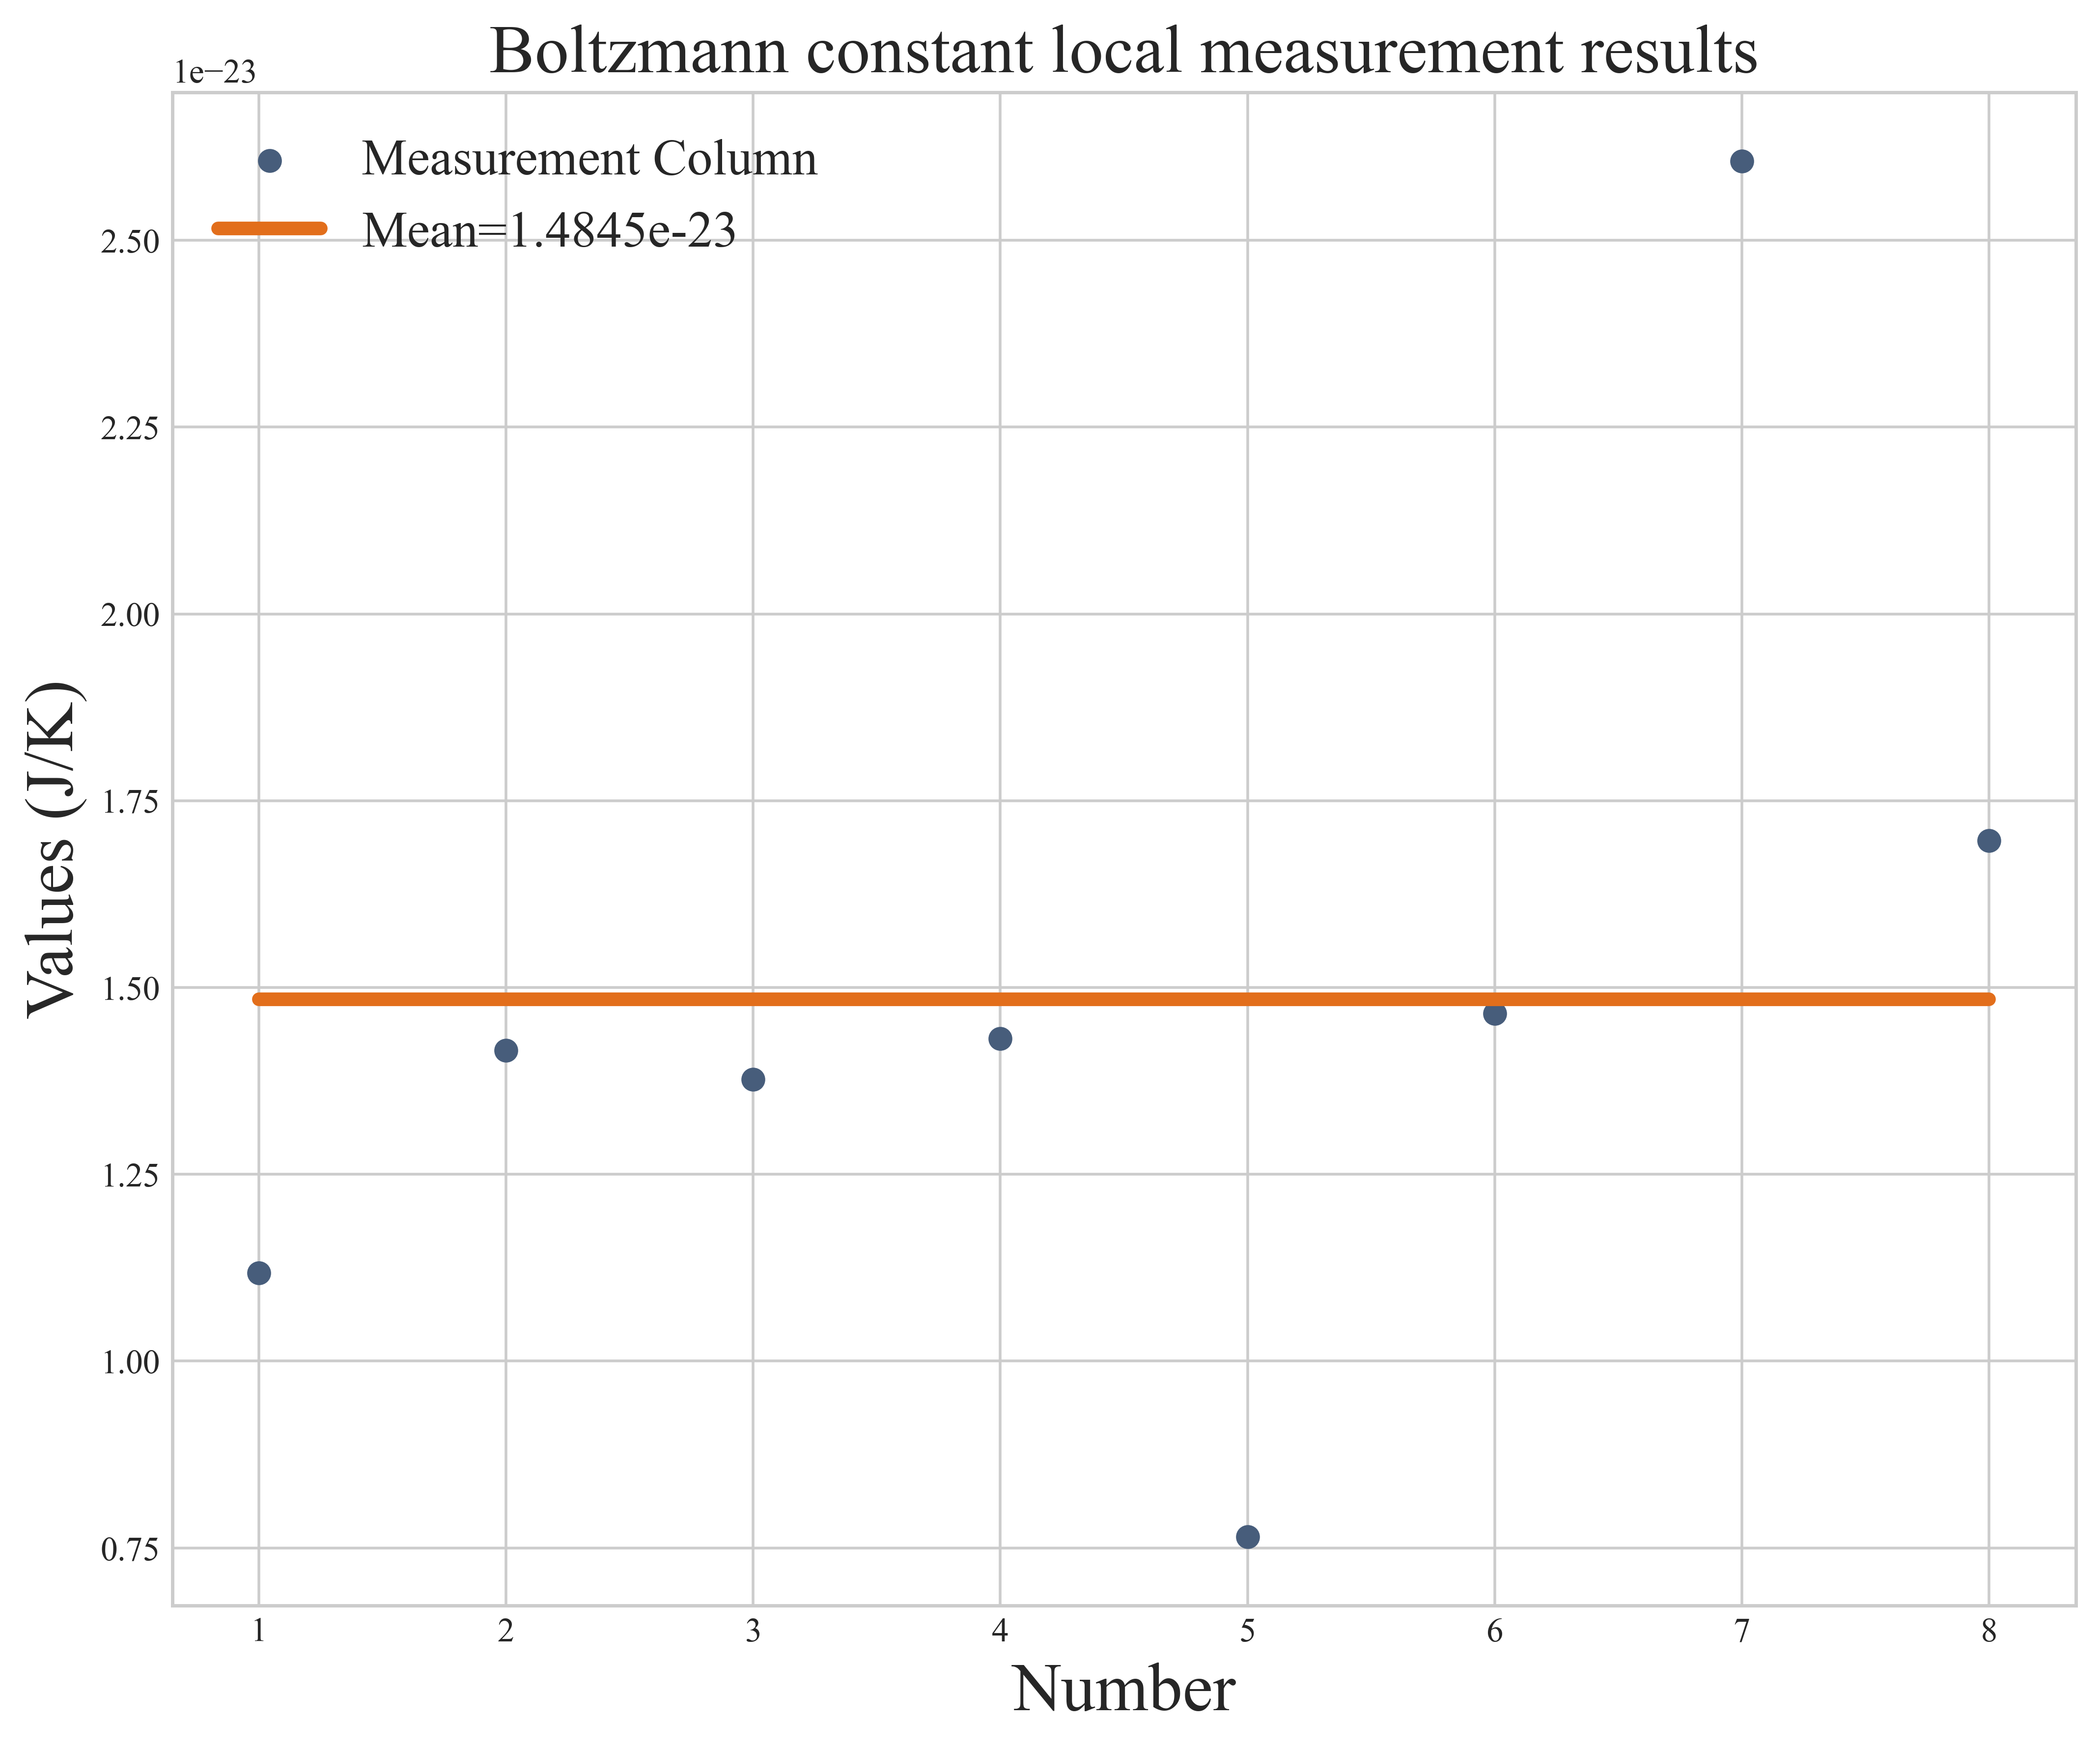

In [6]:
# 本地测量的Boltzmann常量

# 其它数据
T_set = np.array([298.0, 298.0, 298.0, 298.0, 74.3, 74.3, 74.3, 74.3])
f_set = np.array([6666, 1145, 11451, 20486, 666, 6666, 66666, 36666])
tau = 10e-3
R_set = np.array([144.5e3, 144.5e3, 144.5e3, 144.5e3, 144.0e3, 144.0e3, 144.0e3, 144.0e3])
c_slope = 3 / 32

k_B_set_local = []

for i in range(8):
    data = data_set_local[i]
    base = data_set_base[i]
    x = data['X'].values
    y = data['Y'].values
    xb = base['X'].values
    yb = base['Y'].values
    variance_XB = np.var(xb, ddof=1)
    variance_YB = np.var(yb, ddof=1)
    variance_X = np.var(x, ddof=1)
    variance_Y = np.var(y, ddof=1)
    k_B = bcm(T_set[i], f_set[i], tau, R_set[i], c_slope, (variance_X + variance_Y) / 2, (variance_XB + variance_YB) / 2)
    k_B_set_local.append(k_B)

# 输出结果
print('本地测量测量列k_B(local)')
for item in k_B_set_local:
    print(f'{item:.4e}')

# 结果的初步评定
x_arr = np.array([1, 2, 3, 4, 5, 6, 7, 8])
y_arr = np.array(k_B_set_local)
print('本地测量均值：')
print(np.mean(y_arr))

# 可视化
x_lin = np.linspace(1, 8, num=500)
plt.figure()
plt.scatter(x_arr, y_arr, color=colors[1], label='Measurement Column')
plt.plot(x_lin, 0 * x_lin + np.mean(y_arr), color=colors[3], label=f'Mean={np.mean(y_arr):.4e}', linewidth=4)
plt.title('Boltzmann constant local measurement results', fontsize=20)
plt.xlabel('Number')
plt.ylabel('Values (J/K)')
plt.legend(fontsize=15)
plt.show()


In [7]:
# 本底修正（感觉没啥用，不过可能遥测有用）

base_noise = []

for i in range(8):
    base = data_set_base[i]
    xb = base['X'].values
    yb = base['Y'].values
    variance_XB = np.var(xb, ddof=1)
    variance_YB = np.var(yb, ddof=1)
    base_noise.append((variance_XB + variance_YB) / 2)

base_noise_mean = np.mean(np.array(base_noise)) # 感觉用这个就行
print('本底噪声测量列：')
print(base_noise)
print('本底噪声均值：')
print(base_noise_mean)

# 按加权标准差的方式做合成（详见误差分析的教材）
base_noise_weightsum = 0
for item in base_noise:
    base_noise_weightsum = base_noise_weightsum + 1 / item
base_noise_weightmean = 1 / base_noise_weightsum
print('本底噪声加权均值：')
print(base_noise_weightmean)

本底噪声测量列：
[5.159218127159456e-15, 5.422966468043846e-16, 2.839220030245601e-16, 2.57362057558776e-16, 4.328119296701911e-15, 2.4493796193005945e-16, 2.434475705650051e-16, 2.5386909039803277e-16]
本底噪声均值：
1.4141465942677731e-15
本底噪声加权均值：
4.585910604884578e-17


遥测测量列k_B(remote)
1.7189e-23
1.3464e-23
1.3508e-23
1.4270e-23
1.3461e-23
1.8758e-23
1.6233e-23
1.4164e-23
遥测均值：
1.5130918929110046e-23


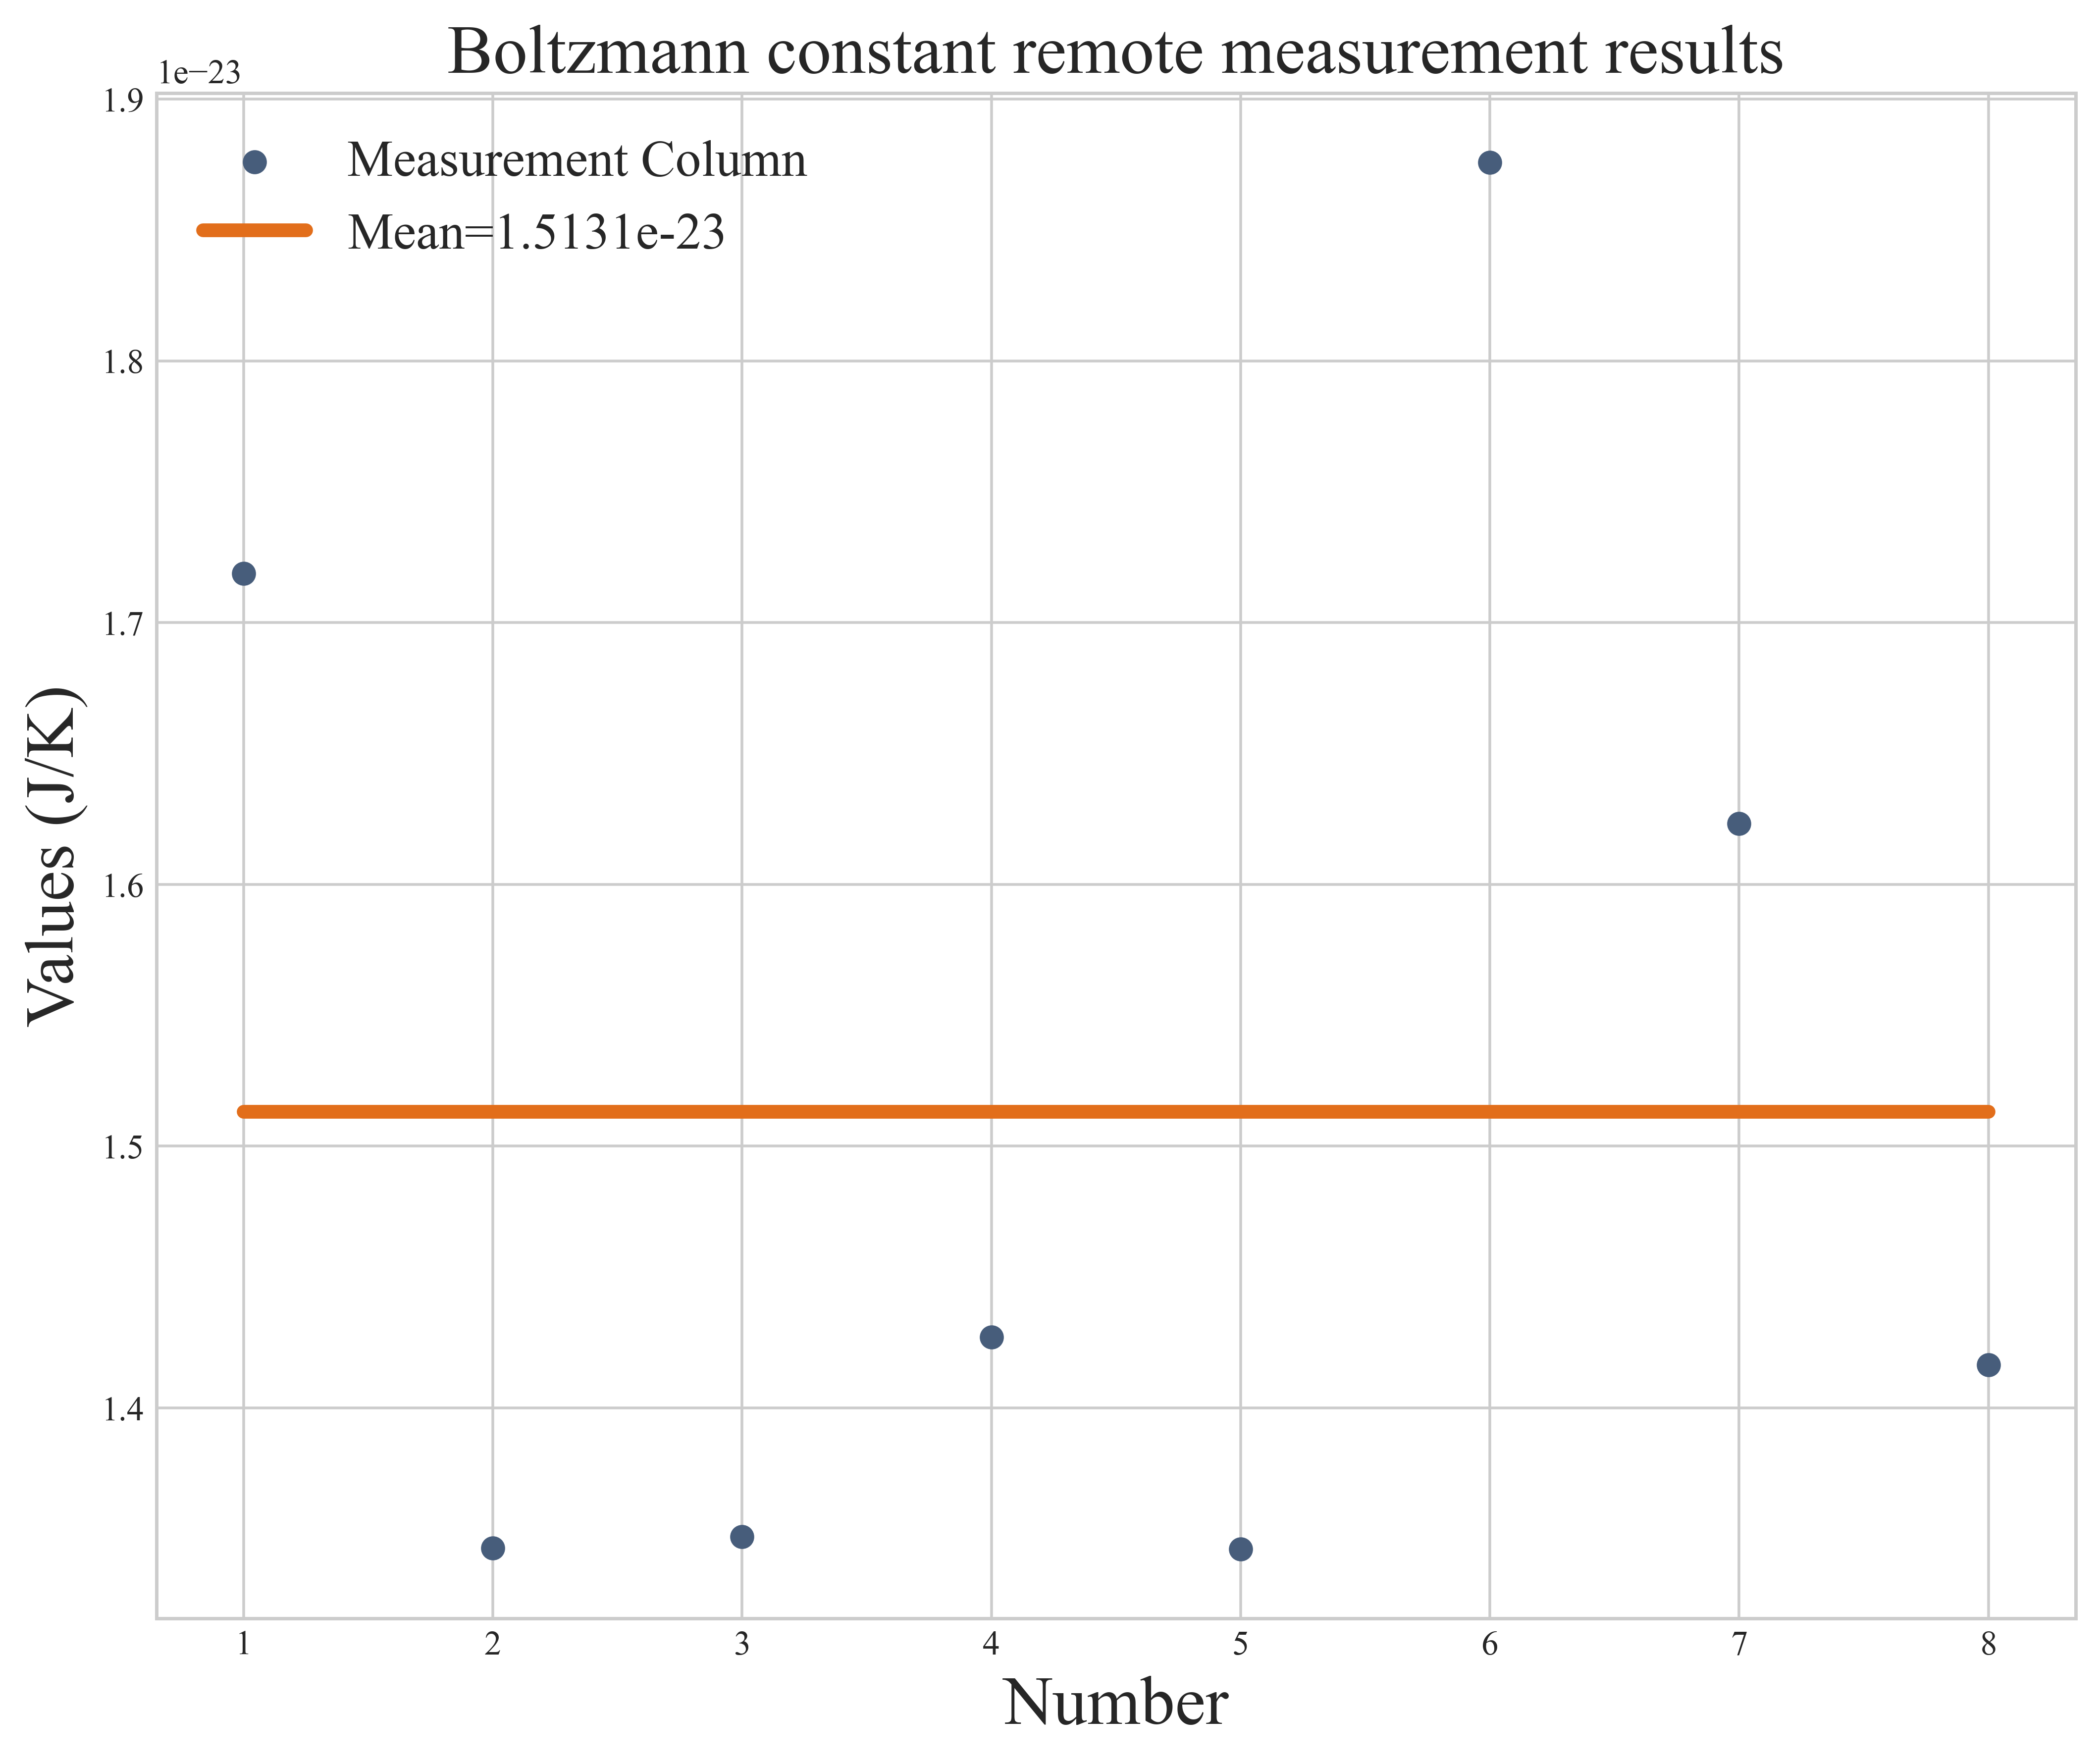

In [ ]:
# 远程测量的Boltzmann常量

# 其它数据
T_set2 = np.array([297.9, 298.0, 298.1, 298.2, 298.3, 298.4, 298.4, 298.5])
f_set2 = np.array([66666, 6666, 666, 888, 8888, 88888, 20, 2326])
tau2 = 100e-3
R_set2 = np.array([144.5e3, 144.5e3, 144.5e3, 144.5e3, 144.5e3, 144.5e3, 144.5e3, 144.5e3])
c_slope2 = 5 / 64

k_B_set_remote = []

for i in range(8):
    data = data_set_remote[i]
    x = data['X'].values
    y = data['Y'].values
    variance_X = np.var(x, ddof=1)
    variance_Y = np.var(y, ddof=1)
    k_B = bcm(T_set2[i], f_set2[i], tau2, R_set2[i], c_slope2, (variance_X + variance_Y) / 2, 0) # 事实证明根本不能那样考虑本底噪声
    k_B_set_remote.append(k_B)

# 输出结果
print('遥测测量列k_B(remote)')
for item in k_B_set_remote:
    print(f'{item:.4e}')

# 结果的初步评定
x_arr2 = np.array([1, 2, 3, 4, 5, 6, 7, 8])
y_arr2 = np.array(k_B_set_remote)
print('遥测均值：')
print(np.mean(y_arr2))

# 可视化
x_lin = np.linspace(1, 8, num=500)
plt.figure()
plt.scatter(x_arr2, y_arr2, color=colors[1], label='Measurement Column')
plt.plot(x_lin, 0 * x_lin + np.mean(y_arr2), color=colors[3], label=f'Mean={np.mean(y_arr2):.4e}', linewidth=4)
plt.title('Boltzmann constant remote measurement results', fontsize=20)
plt.xlabel('Number')
plt.ylabel('Values (J/K)')
plt.legend(fontsize=15)
plt.show()


In [ ]:
# 误差分析

def relative_error(nB2, nx2, M, f, R, T, delta_R=1, delta_T=0.3, delta_alpha_over_alpha=0.01):
    '''
    计算相对误差  
    n_BX: 本底噪声   
    n_TX: 真实噪声值（做修正、扣除本底后）  
    M: 样本数  
    R: 电阻值  
    T: 温度  
    '''
    if T < 100:
        delta_T = 2
    else:
        delta_T=0.3

    # R_in = R
    # C_in = 68e-12
    # omega = 2 * np.pi * f
    # nTx2 = (1 + (omega * R_in * C_in)**2) * nx2 - nB2

    rerror = 3 * np.sqrt((1 + 2 * nB2 / nx2) * (2 / (M - 1)) + np.abs(delta_R / (R**3))**2 + np.abs(delta_T / (T**3))**2 + 4 * delta_alpha_over_alpha**2)
    return rerror

In [ ]:
# 由于只要本地测量测量了本底噪声，所以误差分析只对本地测量进行

M_local = []
for item in data_set_local:
    M_local.append(len(item['X']))

# 其它数据
T_set = np.array([298.0, 298.0, 298.0, 298.0, 74.3, 74.3, 74.3, 74.3])
f_set = np.array([6666, 1145, 11451, 20486, 666, 6666, 66666, 36666])
R_set = np.array([144.5e3, 144.5e3, 144.5e3, 144.5e3, 144.0e3, 144.0e3, 144.0e3, 144.0e3])

rerror = []

for i in range(8):
    data = data_set_local[i]
    x = data['X'].values
    y = data['Y'].values
    variance_X = np.var(x, ddof=1)
    variance_Y = np.var(y, ddof=1)
    nx2 = (variance_X + variance_Y) / 2
    nB2 = base_noise[i]
    rerror.append(relative_error(nB2, nx2, M_local[i], f_set[i], R=R_set[i], T=T_set[i]))

print('相对误差列（本地测量）')
for item in rerror:
    print(f'{item * 100:.2f}%')
    #print(item)

相对误差列（本地测量）
9.90%
9.94%
9.67%
13.72%
16.91%
11.20%
15.99%
11.80%


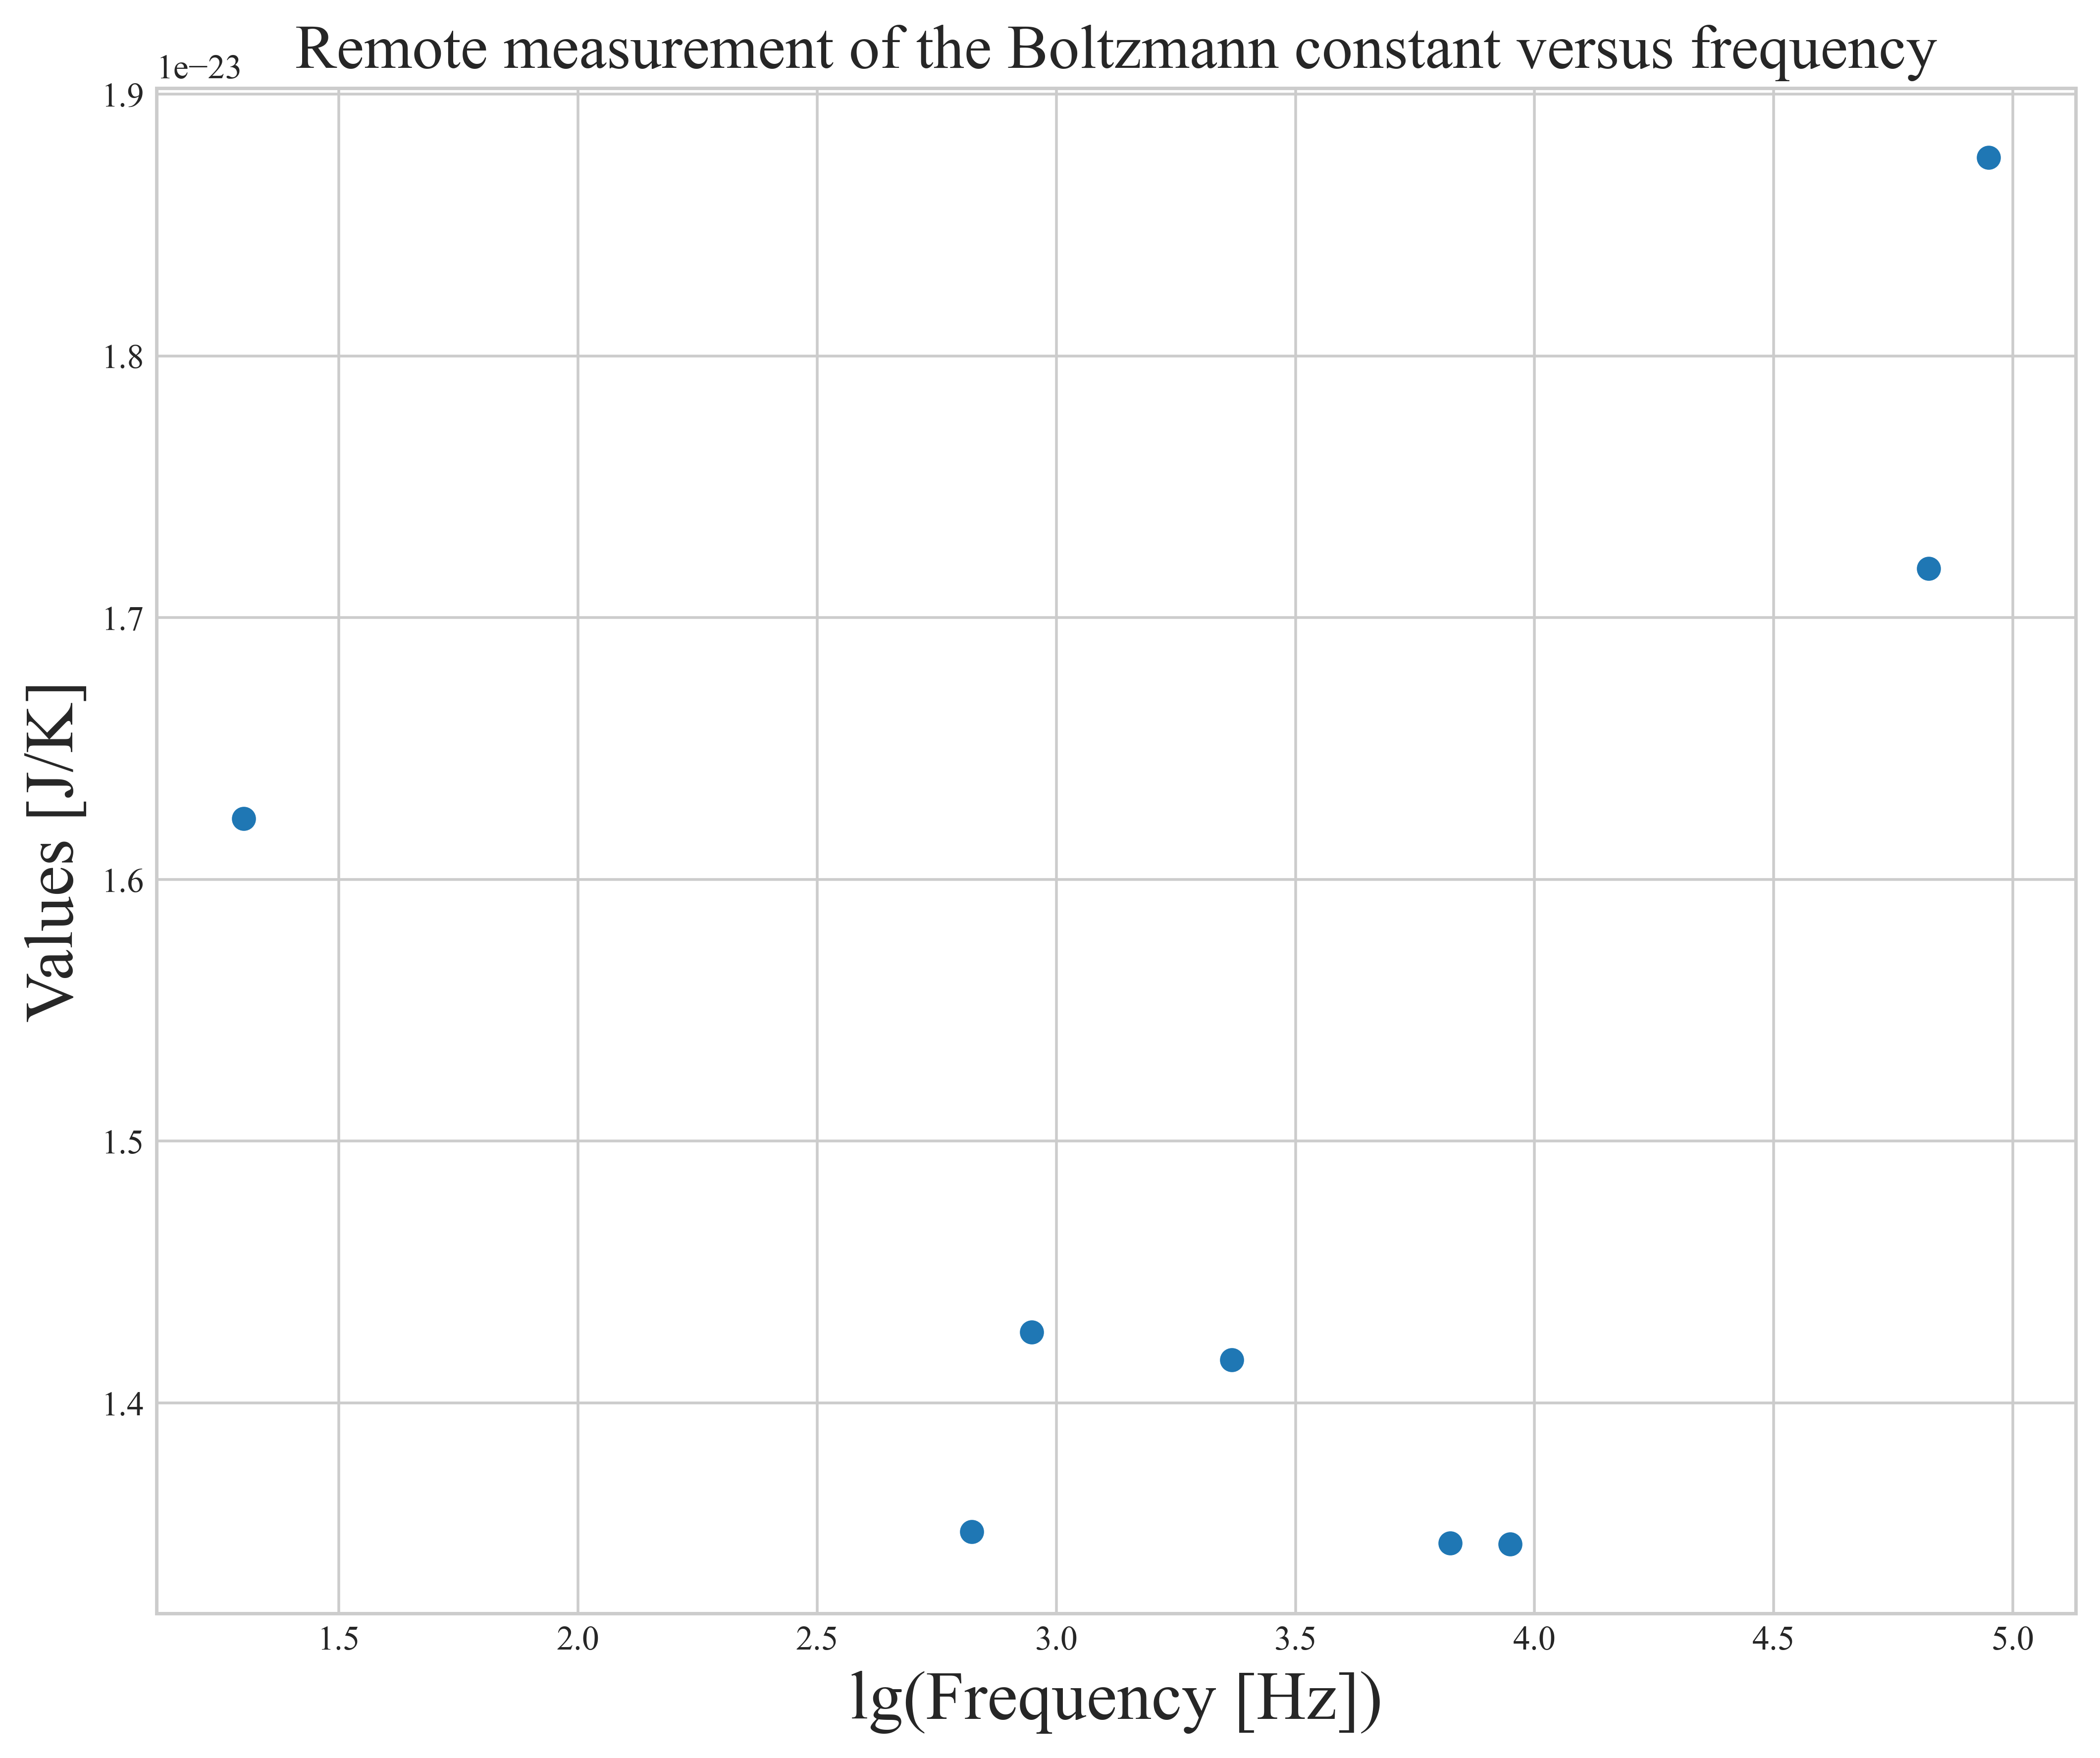

In [ ]:
# 测量结果频域分析

plt.figure()
plt.scatter(np.log10(np.array(f_set2)), np.array(k_B_set_remote), color=colors[3])
plt.title('Remote measurement of the Boltzmann constant versus frequency', fontsize=18)
plt.xlabel('lg(Frequency [Hz])')
plt.ylabel('Values [J/K]')
plt.show()

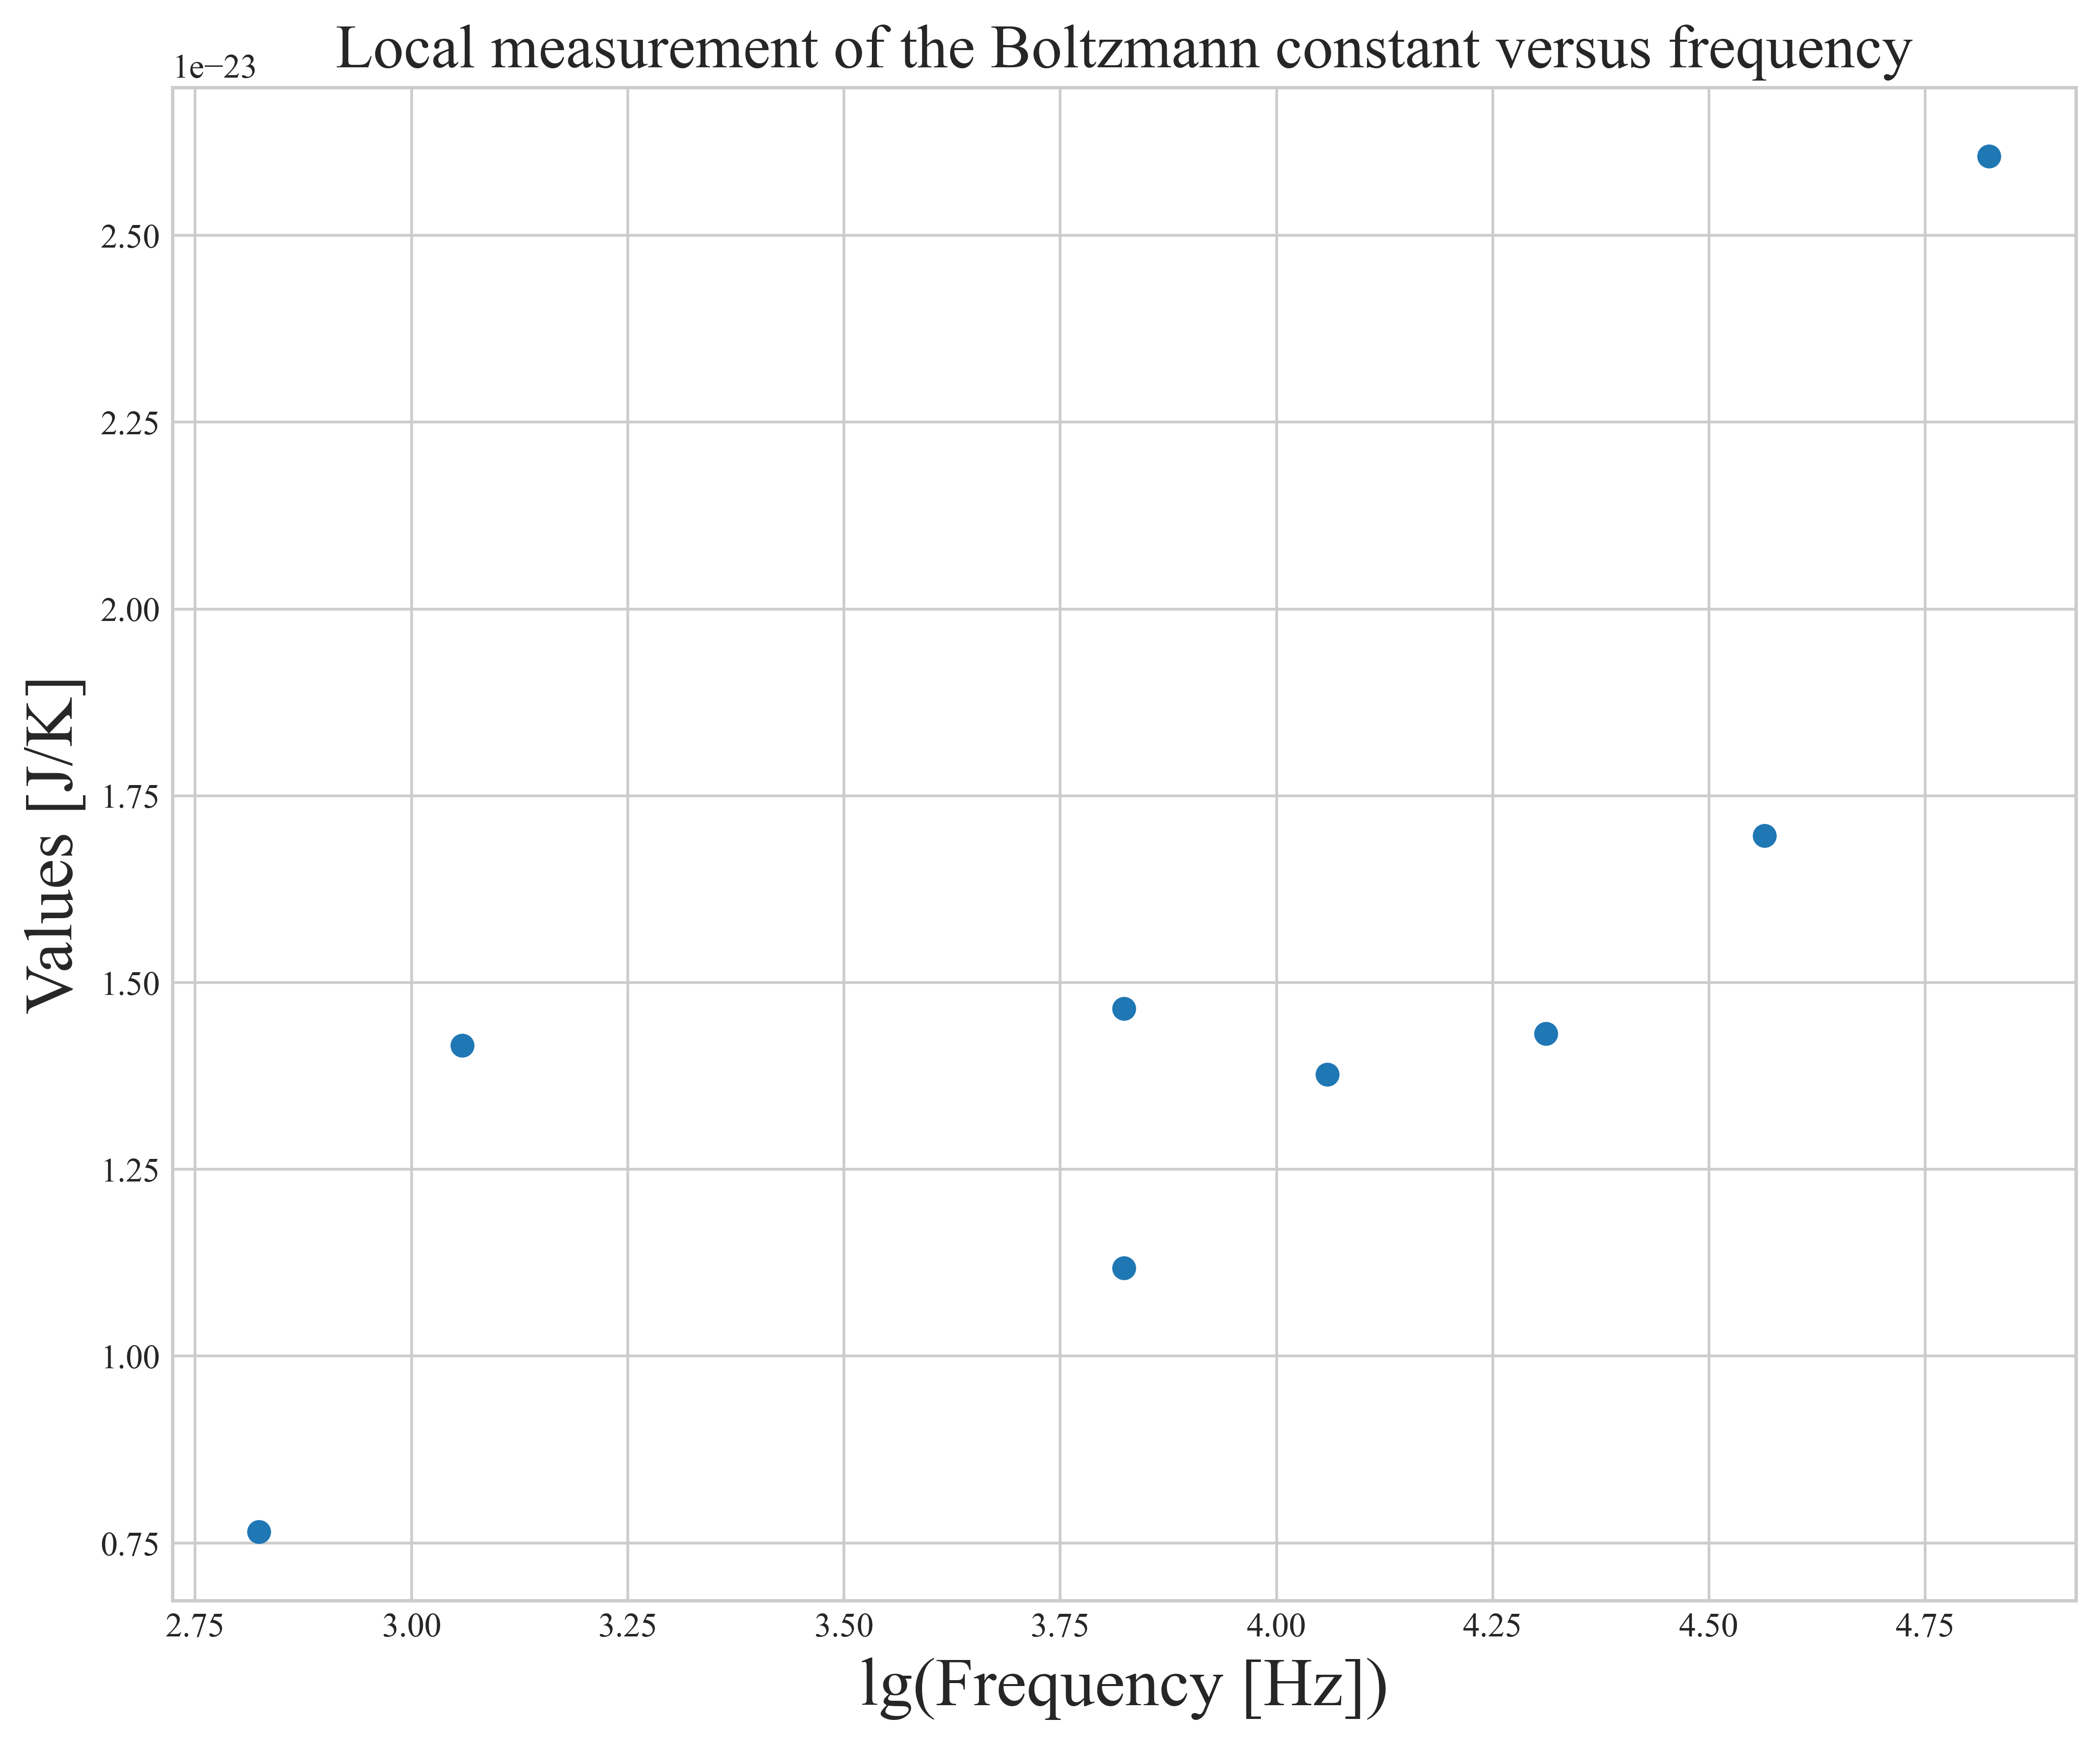

In [ ]:
plt.figure()
plt.scatter(np.log10(np.array(f_set)), np.array(k_B_set_local), color=colors[3])
plt.title('Local measurement of the Boltzmann constant versus frequency', fontsize=18)
plt.xlabel('lg(Frequency [Hz])')
plt.ylabel('Values [J/K]')
plt.show()

In [ ]:
# 相关性检验

def correlation_test(x, y, label='Data'):
    '''
    Calculate the Pearson and Spearman correlation coefficients for two columns of data.
    '''
    print('对数据'+label+'进行相关性分析，结果如下所示：\n')

    # 1. 皮尔逊相关系数
    pearson_corr, pearson_p = stats.pearsonr(x, y)
    print("Pearson Correlation Coefficient:")
    print(f"Coefficient: {pearson_corr:.4f}, p-value: {pearson_p:.4f}")
    if pearson_p < 0.05:
        print("结论：在显著性水平 0.05 下，两列数据存在显著的线性相关性 (p <= 0.05)\n")
    else:
        print("结论：在显著性水平 0.05 下，两列数据不存在显著的线性相关性 (p > 0.05)\n")

    # 2. 斯皮尔曼相关系数
    spearman_corr, spearman_p = stats.spearmanr(x, y)
    print("Spearman Correlation Coefficient:")
    print(f"Coefficient: {spearman_corr:.4f}, p-value: {spearman_p:.4f}")
    if spearman_p < 0.05:
        print("结论：在显著性水平 0.05 下，两列数据存在显著的非参数相关性 (p <= 0.05)\n")
    else:
        print("结论：在显著性水平 0.05 下，两列数据不存在显著的非参数相关性 (p > 0.05)\n")
    
    return None

In [ ]:
correlation_test(np.array(f_set), np.array(k_B_set_local), label="“本地测量所得各玻尔兹曼常数测量值”")
correlation_test(np.array(f_set2), np.array(k_B_set_remote), label="“本地测量所得各玻尔兹曼常数测量值”")

对数据Data进行相关性分析，结果如下所示：

Pearson Correlation Coefficient:
Coefficient: 0.9145, p-value: 0.0015
结论：在显著性水平 0.05 下，两列数据存在显著的线性相关性 (p <= 0.05)

Spearman Correlation Coefficient:
Coefficient: 0.7904, p-value: 0.0195
结论：在显著性水平 0.05 下，两列数据存在显著的非参数相关性 (p <= 0.05)

